# Assignment 1:  data analysis with pandas

Note:  in this assignment do not use pandas functionality that we haven't covered in class unless explicitly suggested.

## Part 1: tipping data

Your task is to analyze data related to tipping at restaurants.

First we'll read the data into a pandas data frame:

In [1]:
import pandas as pd

In [2]:
data_url = "https://github.com/mwaskom/seaborn-data/raw/master/tips.csv"
data = pd.read_csv(data_url)
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


The information provided in this data includes the following:  

* **total_bill** - the bill before tip
* **tip** - amount paid as tip
* **sex** - the gender of the person paying the bill
* **smoker** - whether the person paying the bill is a smoker
* **day** - day of the week
* **time** - whether the meal was "Lunch" or "Dinner".
* **size** - how many people were part of the party

In this part of the assignment we will look for tendencies of people when tipping.

Here are your tasks:

#### Tip amount

* Compare the avergae tip amount between lunch and dinner.  Use the `mean()` method of a `Series/DataFrame`.  In which meal do you observe a larger tip?
Dinner

In [3]:


data.groupby("time")["tip"].mean()

,tip
time,
Dinner,3.102670
Lunch,2.728088


#### Tip percentage

* You should observe a larger tip amount for dinner.  However, is this really the right question to ask?  Dinners tend to cost more, so it is to be expected that the tip amount will be larger.  But is the tip percentage much different?  To answer this question, add another column called `tip_percentage` to the ``DataFrame`` which contains the tip percentage (tip amount / total_bill) * 100.  With that added information, what were the smallest and largest tip percentages?  Use the `min` and `max` method to determine that.

In [37]:
# add tip percentage column and determine min / max amounts
data["tip_percentage"] = ((data["tip"]/data["total_bill"]) * 100)

print(data)

data["tip_percentage"].min(), data["tip_percentage"].max()


     total_bill   tip     sex smoker   day    time  size  tip_percentage
0         16.99  1.01  Female     No   Sun  Dinner     2        5.944673
1         10.34  1.66    Male     No   Sun  Dinner     3       16.054159
2         21.01  3.50    Male     No   Sun  Dinner     3       16.658734
3         23.68  3.31    Male     No   Sun  Dinner     2       13.978041
4         24.59  3.61  Female     No   Sun  Dinner     4       14.680765
..          ...   ...     ...    ...   ...     ...   ...             ...
239       29.03  5.92    Male     No   Sat  Dinner     3       20.392697
240       27.18  2.00  Female    Yes   Sat  Dinner     2        7.358352
241       22.67  2.00    Male    Yes   Sat  Dinner     2        8.822232
242       17.82  1.75    Male     No   Sat  Dinner     2        9.820426
243       18.78  3.00  Female     No  Thur  Dinner     2       15.974441

[244 rows x 8 columns]


(3.563813585135547, 71.0344827586207)

#### Tip percentage in lunch vs dinner

* Next, compare the average tip percentage between lunch and dinner.  You should observe a pretty small difference.

In [10]:
data.groupby("time")["tip_percentage"].mean()

,tip_percentage
time,
Dinner,15.951779
Lunch,16.412793


#### Tip by gender

* Compare the average tip percentage given by gender.  Also create a histogram that compares the distribution of tips given across genders.
DataFrames have a [histogram](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html) method for this task.

sex
Female    16.649074
Male      15.765055
Name: tip_percentage, dtype: float64


array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

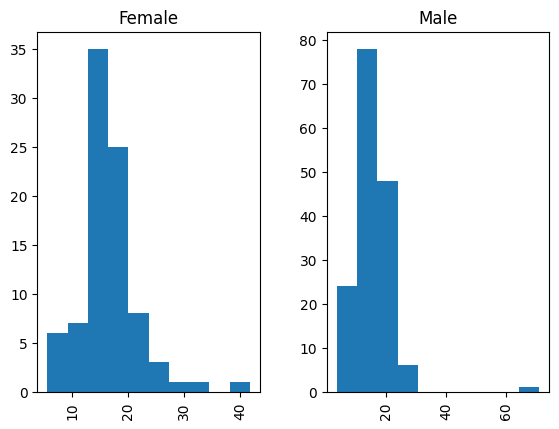

In [39]:

print(data.groupby("sex")["tip_percentage"].mean())
data.hist(column="tip_percentage", by= "sex")


## Part 2:  baby names in Colorado

The US Social Security Administration has been keeping track of baby names in the US since the late 1800's.  In this part of the assignment we will track some trends in this data.
This data is collected from applications for social security cards; the original version is available [here](https://catalog.data.gov/dataset/baby-names-from-social-security-card-applications-national-data).  We will use a smaller subset of data found below.

We'll focus on data collected in Colorado from 1910.  The first few lines of the data file are as follows:

```
CO,F,1910,Mary,193
CO,F,1910,Helen,112
CO,F,1910,Dorothy,87
CO,F,1910,Ruth,68
CO,F,1910,Margaret,67
```

The first column specifies the state (Colorado), the second column is the gender (F/M), the third column is the year (1910-2018), and the last column is the count of Colorado babies that were given that name during that year.

First, let's load the data straight into the Jupyter notebook:

#### Reading in the data

We'll use the pandas `read_csv` function to read the data:

In [7]:
data_url = 'https://www.cs.colostate.edu/~asa/courses/dsci235/spr21/data/co.txt'
names = pd.read_csv(data_url)
names.head()

,CO,F,1910,Mary,193
0,CO,F,1910,Helen,112
1,CO,F,1910,Dorothy,87
2,CO,F,1910,Ruth,68
3,CO,F,1910,Margaret,67
4,CO,F,1910,Frances,56


As you can see, this does not give the desired result:  the first row was interpreted as the column names for this dataset.
Modify the command so that the first row is read correctly and columns are given the following descriptive names: 'state', 'gender', 'year', 'name', and 'count'.
You can refer to the [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) documentation on how to do that.

In [8]:
# code for reading the data into a DataFrame with columns named
# appropriately
names = pd.read_csv(data_url,names = ["state","gender","year","name","count"])

names

,state,gender,year,name,count
0,CO,F,1910,Mary,193
1,CO,F,1910,Helen,112
2,CO,F,1910,Dorothy,87
3,CO,F,1910,Ruth,68
4,CO,F,1910,Margaret,67
...,...,...,...,...,...
107218,CO,M,2018,Westley,5
107219,CO,M,2018,Westyn,5
107220,CO,M,2018,Yariel,5
107221,CO,M,2018,Zavian,5


#### Most popular name

* What was the most popular male baby name in 2018?  What was the most popular female baby name in 2018?  You can use the method `idxmax`.


In [9]:
from numpy._core.defchararray import count
from os import name
name2018 = names.loc[(names['year'] == 2018), ['gender','name','count']]
name2018
index = name2018.groupby('gender')['count'].idxmax()
name2018.loc[index]



,gender,name,count
58637,F,Olivia,325
106328,M,Liam,331


#### Top 5 most popular names

* What were the five most popular baby names in 2018? You can use a DataFrame's `nlargest` or `sort_values` methods.

In [10]:
name2018.sort_values('count', ascending= False).head(5)

,gender,name,count
106328,M,Liam,331
58637,F,Olivia,325
106329,M,Oliver,274
106330,M,William,266
58638,F,Emma,266


#### Unisex names

* First, let's define a name as being *popular* if its count is above some threshold.
Find names that are popular in both genders in the same year.
Compute this for names given in 2018, and use a threshold of 30 to define popularity.  As a hint, on ways to solve this, the pandas [isin](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html) or [duplicated](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html) DataFrame methods can be used for this task (think how they might be useful!)

In [11]:
pop2018 = name2018[(name2018['count']) >= 30]
unisex2018 = pop2018[pop2018.duplicated('name',keep= False)].sort_values('name')
unisex2018

,gender,name,count
58648,F,Avery,166
106547,M,Avery,30
58808,F,Blake,31
106538,M,Blake,31
58741,F,Charlie,47
106523,M,Charlie,34
58734,F,Emerson,51
106517,M,Emerson,35
58796,F,Parker,34
106450,M,Parker,55


#### Counts over time

* Choose a unisex name and create a DataFrame that summarizes its count over time separately for males and females between 1910 and 2018.  Plot the data using the `plot` method of a DataFrame (see [DataFrame.plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html) for details) or the Matplotlib [plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) function.  Matplotlib offers more flexibility, and might help you more easily get the result you are looking for.

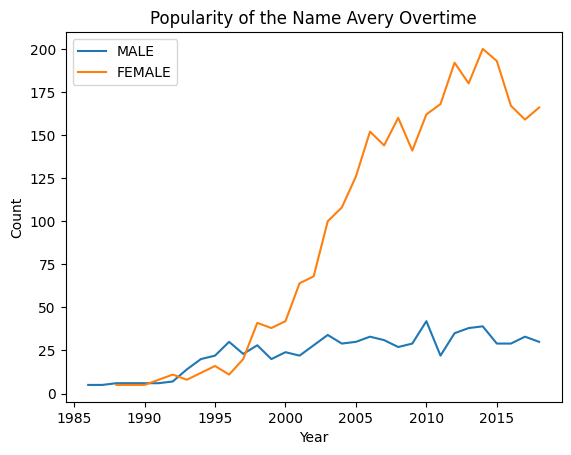

In [45]:
import matplotlib.pyplot as plt

counts_Avery = names[(names['name']=='Avery') & (names['year'] >=1910) &
                     (names['year']<= 2018)]
m_Avery = counts_Avery[counts_Avery['gender'] == 'M']

f_Avery = counts_Avery[counts_Avery['gender'] == 'F']



plt.plot(m_Avery['year'],  m_Avery['count'], label = 'MALE')

plt.plot(f_Avery['year'], f_Avery['count'], label = 'FEMALE')

plt.xlabel('Year')
plt.ylabel('Count')
plt.title("Popularity of the Name Avery Overtime")
plt.legend()
plt.show()


#### Increase in popularity

* Which name has shown the largest increase in popularity from 2017 to 2018?  Do this for both men and women.  This will require you to subtract two DataFrame or Series objects.  If a name is present in one year but not the other, this can lead to the appearance of `NaN`s.  To address this issue we suggest to use the [subtract](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.subtract.html) method of a DataFrame/Series object.


In [23]:
name_2017_M = names[(names['year'] == 2017) & (names['gender'] == 'M')]
name_2018_M = names[(names['year']== 2018) & (names['gender']=='M')]
name_2017_F = names[(names['year'] == 2017) & (names['gender'] == 'F')]
name_2018_F = names[(names['year']== 2018) & (names['gender']=='F')]

m_17 = name_2017_M.set_index('name')['count']
m_18 = name_2018_M.set_index('name')['count']
f_17 = name_2017_F.set_index('name')['count']
f_18 = name_2018_F.set_index('name')['count']


m_change = m_18.sub(m_17, fill_value=0)
f_change = f_18.sub(f_17, fill_value=0)

m_change.idxmax(),f_change.idxmax()






('Nolan', 'Olivia')

#### Earliest occurrence of a name

* What year did "Taylor" make its first appearance as a female name?  As a male name?  You can use the fact that the file is sorted by year.

In [35]:
male_names = names[(names['gender']=='M')]
female_names = names[(names['gender']=='F')]

taylor_f = female_names[(female_names['name']=='Taylor')]
taylor_m = male_names[(male_names['name']== 'Taylor')]
taylor_f

taylor_f['year'].min(), taylor_m['year'].min()




(1981, 1968)

### Submission

Submit your assignment as a Jupyter notebook via Canvas.  

### Grading

Here is what the grade sheet will look like for this assignment.

```
Grading sheet for assignment 1

Tips data (40 pts)

  Tip amount at lunch and dinner (10 pts)
  Tip-percentage column (10 pts)
  Comparison of tip percentage between lunch and dinner (10 pts)
  Comparison of tip percentage by gender (10 pts)

Baby names (60 pts)

  Read the data and store it in a DataFrame (10 pts)
  Most common baby name (5 pts)
  Top 5 baby names (5 pts)
  Unisex names (10 pts)
  Counts over time (10 pts)
  Increase in popularity (10 pts)
  Earliest occurrence (10 pts)

```

Throughout the course, use of for loops is discouraged.  **Points will be taken off for using for loops unless explicitly allowed.**  pandas provides tools for accomplishing things without the need for Python loops.
